In [6]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("../data/cleaned/sales_cleaned.csv")

df.head()

print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Month Name', 'Year Month']


In [8]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)

In [9]:
reference_date = df["Order Date"].max() + pd.Timedelta(days=1)

customer_data = (
    df.groupby("Customer ID")
    .agg({
        "Order Date": lambda x: (reference_date - x.max()).days,
        "Order ID": "nunique",
        "Sales": "sum"
    })
    .reset_index()
)

customer_data.columns = [
    "Customer ID",
    "Recency",
    "Frequency",
    "Monetary"
]

customer_data.head()

,Customer ID,Recency,Frequency,Monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156


In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = [
    "Recency",
    "Frequency",
    "Monetary"
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    customer_data[features]
)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(
    X_scaled
)

customer_data.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,AA-10315,185,5,5563.560,0
1,AA-10375,20,9,1056.390,3
2,AA-10480,260,4,1790.512,0
3,AA-10645,56,6,5086.935,3
4,AB-10015,416,3,886.156,1


In [11]:
print(
    customer_data["Cluster"].value_counts().sort_index()
)

Cluster
0    340
1    103
2     67
3    294
Name: count, dtype: int64


In [12]:
cluster_summary = (
    customer_data
    .groupby("Cluster")[features]
    .mean()
    .round(2)
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,98.67,4.71,1615.68
1,546.15,3.84,1585.02
2,113.88,8.58,9449.93
3,70.65,8.66,3336.06


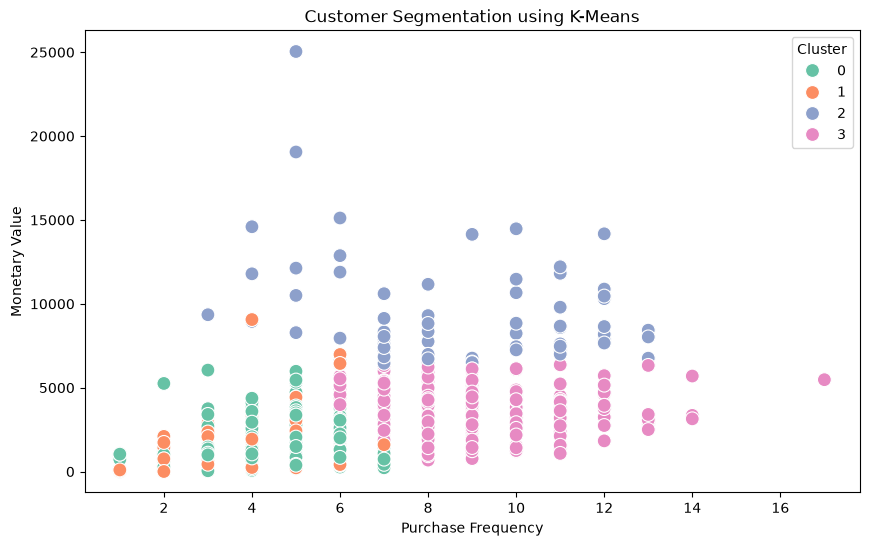

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_data,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=100
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.show()

In [14]:
customer_data.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

print("Customer segmentation saved successfully!")

Customer segmentation saved successfully!


In [15]:
cluster_summary = (
    customer_data
    .groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,98.67,4.71,1615.68
1,546.15,3.84,1585.02
2,113.88,8.58,9449.93
3,70.65,8.66,3336.06


In [16]:
cluster_names = {
    0: "High-Value Frequent Customers",
    1: "Low-Frequency Customers",
    2: "Recent Customers",
    3: "Inactive Customers"
}

customer_data["Cluster Name"] = customer_data["Cluster"].map(
    cluster_names
)

In [17]:
customer_data.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Cluster Name
0,AA-10315,185,5,5563.560,0,High-Value Frequent Customers
1,AA-10375,20,9,1056.390,3,Inactive Customers
2,AA-10480,260,4,1790.512,0,High-Value Frequent Customers
3,AA-10645,56,6,5086.935,3,Inactive Customers
4,AB-10015,416,3,886.156,1,Low-Frequency Customers


In [18]:
customer_data.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

print("Customer segmentation saved successfully!")

Customer segmentation saved successfully!
